In [1]:
!pip install networkx python-louvain

 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 4.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=82b86934f7e128ec7e639e156975a1e660fb055dad978f4b369fe6f1324b2ca9
  Stored in directory: /home/marcelly/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain


In [ ]:
#--BUILD k-NN GRAPH WITH reweighed_intersectional_with_age.csv--#

In [7]:
#Checking for best k 

import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix, csgraph
import matplotlib.pyplot as plt


def sweep_k_for_knn_age_weighted(
    df_scaled: pd.DataFrame,
    *,
    scaled_col: str = "AGEP_A_scaled",
    weight_col: str = "instance_weight",
    ks=tuple(range(3, 31)),
    target_gcc: float = 0.98,       # target *weighted* GCC coverage
    dtype=np.float32,
    compute_weights: bool = True,   # also compute RBF sigma & mean similarity
    age_col: str | None = "AGEP_A",
    age_min: float | None = None,
    age_max: float | None = None,
    verbose: bool = True,
    mean_degree_cap: float = 25.0,  # soft cap to avoid overly dense graphs
):
   # feature matrix: just the (n x 1) age-scaled column
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]

   #weights: use instance_weight 
    if weight_col in df_scaled.columns:
        weights = pd.to_numeric(df_scaled[weight_col], errors="coerce").to_numpy(dtype=np.float32)
        
        # Replace NaN/negatives with 0; typical survey weights should be > 0
        weights = np.where(np.isfinite(weights) & (weights > 0.0), weights, 0.0)
    else:
        # Fallback to uniform weights if missing 
        weights = np.ones(n, dtype=np.float64)

    total_weight = float(weights.sum())
    if total_weight <= 0.0:
        # Guard: if all weights are zero, weighted coverage is meaningless
        total_weight = 1.0
    
    results = []

    for k in ks:
        k_eff = min(max(1, k), max(1, n-1)) # clamp to [1, n-1]

        # # Directed kNN graph with distances (Euclidian)
        A_dist = kneighbors_graph(
            X, n_neighbors=k_eff, mode="distance",
            metric="euclidean", include_self=False, n_jobs=-1
        ).tocsr().astype(dtype)

        # unweighted, undirected union graph for connectivity stats 
        U = (A_dist + A_dist.T)            # union
        U.data[:] = 1.0                    # binarize
        U = U.tocsr()                      # ensure CSR

        # connected components
        n_comp, labels = csgraph.connected_components(U, directed=False)
        
        # Unweighted giant component (GCC) fraction
        if n_comp > 0:
            _, counts = np.unique(labels, return_counts=True)
            gcc_frac = counts.max() / n
        else:
            gcc_frac = 0.0


         # Weighted GCC fraction
        if n_comp > 0:
            # Sum weights per component (labels are 0..n_comp-1)
            comp_weight = np.bincount(labels, weights=weights, minlength=n_comp)
            gcc_weight_frac = float(comp_weight.max() / total_weight)
        else:
            gcc_weight_frac = 0.0

        # edges & degree
        undirected_edges = U.nnz // 2
        mean_degree = float(U.sum(axis=1).mean())

        row = {
            "k": k_eff,
            "n_components": n_comp,
            "giant_component_frac": gcc_frac,
            "giant_component_weight_frac": float(gcc_weight_frac),# weighted (selection criterion)
            "edges_undirected": undirected_edges,
            "mean_degree": mean_degree,
        }

        # convert distances into RBF weights and summarize
        if compute_weights:
            nz = A_dist.data
            sigma = float(np.median(nz)) if nz.size else 1.0
            W = A_dist.tocsr(copy=True)
             # Gaussian kernel on distances
            W.data = np.exp(-(W.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)
            W = ((W + W.T) * 0.5).tocsr()  # symmetric
            row.update({
                "sigma_median": sigma,
                "mean_similarity": float(W.data.mean()) if W.nnz else 0.0
            })

        results.append(row)

    df_res = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

    # Select k using *weighted* GCC criterion
    crit = "giant_component_weight_frac"
    candidates = df_res[df_res[crit] >= target_gcc]
    if not candidates.empty:
        soft = candidates[candidates["mean_degree"] <= mean_degree_cap]
        pick_from = soft if not soft.empty else candidates
        recommended_k = int(pick_from.iloc[0]["k"])  # smallest k wins due to sort
    else:
        # No k reaches the target -> pick the one with the largest *weighted* GCC;
        # break ties by smaller k.
        best_row = df_res.sort_values([crit, "k"], ascending=[False, True]).iloc[0]
        recommended_k = int(best_row["k"])

    # Look up sigma* for the chosen k 
    sigma_star = None
    if compute_weights and "sigma_median" in df_res.columns:
        sigma_star = float(df_res.loc[df_res["k"] == recommended_k, "sigma_median"].iloc[0])

    # Pretty age bounds for logging
    used_age_min = age_min
    used_age_max = age_max
    if (used_age_min is None or used_age_max is None) and age_col and (age_col in df_scaled.columns):
        used_age_min = float(df_scaled[age_col].min())
        used_age_max = float(df_scaled[age_col].max())

    if verbose:
        print(f"Recommended k (by WEIGHTED GCC ≥ {target_gcc:.2%}): {recommended_k}")
        if sigma_star is not None:
            print(f"Sigma* (median kNN distance at k={recommended_k}): {sigma_star:.6f}")
        # Report both unweighted and weighted coverage at k*
        at_k = df_res[df_res["k"] == recommended_k].iloc[0]
        print(f"At k={recommended_k}: GCC (unweighted) = {at_k['giant_component_frac']:.3f}, "
              f"GCC (weighted) = {at_k['giant_component_weight_frac']:.3f}")
        if used_age_min is not None and used_age_max is not None:
            print(f"Age scaling used: min={used_age_min:.3f}, max={used_age_max:.3f}")
        else:
            smin = float(df_scaled[scaled_col].min())
            smax = float(df_scaled[scaled_col].max())
            print(f"Scaled range for '{scaled_col}': [{smin:.6f}, {smax:.6f}]")

    return df_res, recommended_k



if __name__ == "__main__":
    
    # Load as-is (you said the needed columns are present with no missing ages)
    df = pd.read_csv("reweighed_intersectional_with_age.csv")

    # ensure numeric dtypes for safety (won't drop rows)
    for c in ["AGEP_A", "AGEP_A_scaled", "instance_weight"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df_scaled_age = df 

    # Run the sweep
    df_metrics, k_star = sweep_k_for_knn_age_weighted(
        df_scaled_age,
        scaled_col="AGEP_A_scaled",
        weight_col="instance_weight",
        ks=range(5, 31),
        target_gcc=0.98,
        compute_weights=True,
        age_col="AGEP_A",
        age_min=float(df["AGEP_A"].min()),
        age_max=float(df["AGEP_A"].max()),
        verbose=True,
        mean_degree_cap=25.0
    )

    print("\nMetrics (first 5 rows):")
    print(df_metrics.head())

Recommended k (by WEIGHTED GCC ≥ 98.00%): 30
Sigma* (median kNN distance at k=30): 0.000000
At k=30: GCC (unweighted) = 0.001, GCC (weighted) = 0.001
Age scaling used: min=18.000, max=99.000

Metrics (first 5 rows):
   k  n_components  giant_component_frac  giant_component_weight_frac  \
0  5         29460              0.000034                     0.000066   
1  6         29454              0.000238                     0.000231   
2  7         29453              0.000272                     0.000265   
3  8         29452              0.000305                     0.000303   
4  9         29451              0.000339                     0.000337   

   edges_undirected  mean_degree  sigma_median  mean_similarity  
0                 0     0.000000           0.0         0.503590  
1                 6     0.000407           0.0         0.504176  
2                12     0.000815           0.0         0.504766  
3                18     0.001222           0.0         0.505359  
4              

In [11]:
# Build k-NN graph based on age-only geometry + weight-aware pruning
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neighbors import kneighbors_graph
from scipy import sparse

def _norm01(x, mode="logminmax"):
    x = pd.to_numeric(x, errors="coerce").to_numpy(np.float64)
    x = np.where(np.isfinite(x) & (x > 0), x, 0.0)
    if x.max() == 0.0:
        return np.zeros_like(x, dtype=np.float32)
    if mode == "logminmax":
        x = np.log1p(x)
    # min-max to [0,1]
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    return x.astype(np.float32)

def build_knn_from_pre_scaled_weight_pruned(
    df_scaled,
    scaled_col="AGEP_A_scaled",
    weight_col="instance_weight",
    k=30,
    sigma=None,
    alpha=1.0,               # weight influence (0 = ignore)
    prune_threshold=0.25,    # edges with final sim < threshold are dropped
    weight_transform="logminmax",
    symmetrize="mean",       # 'mean' or 'max'
    save_prefix="age_weight_pruned_adjacency",  # saved as: <prefix>.npz and <prefix>_params.json
    dtype=np.float32,
    sigma_floor=1e-4
):
    # guards
    if scaled_col not in df_scaled.columns:
        raise ValueError(f"Missing column: {scaled_col}")
    if weight_col not in df_scaled.columns:
        raise ValueError(f"Missing column: {weight_col}")

    # feature (age similarity only)
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]
    k = min(max(1, int(k)), max(1, n-1))

    # kNN distances (directed)
    A_dist = kneighbors_graph(
        X, n_neighbors=k, mode="distance",
        metric="euclidean", include_self=False, n_jobs=-1
    ).tocsr().astype(dtype)

    # sigma: median nonzero neighbor distance
    if sigma is None:
        nz = A_dist.data
        pos = nz[nz > 0]
        sigma = float(np.median(pos)) if pos.size else 0.01
    sigma = max(float(sigma), sigma_floor)

    #  distance -> RBF similarity
    A_sim = A_dist.tocsr(copy=True)
    A_sim.data = np.exp(-(A_sim.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)

    # weight-aware edge scaling: (wf_i * wf_j)^(alpha/2)
    wf = _norm01(df_scaled[weight_col], mode=weight_transform)
    if alpha != 0.0:
        indptr, indices, data = A_sim.indptr, A_sim.indices, A_sim.data
        left = np.repeat(wf, np.diff(indptr))      # wf[i]
        right = wf[indices]                        # wf[j]
        A_sim.data = (data * (left * right) ** (0.5 * alpha)).astype(dtype)

    #  symmetrize
    if symmetrize == "mean":
        A_sim = ((A_sim + A_sim.T) * 0.5).tocsr()
    elif symmetrize == "max":
        A_sim = (A_sim.maximum(A_sim.T)).tocsr()
    else:
        raise ValueError("symmetrize must be 'mean' or 'max'")

    # prune by threshold (using instance_weights to rescale similarities)
    if prune_threshold is not None and prune_threshold > 0.0:
        C = A_sim.tocoo()
        keep = C.data >= float(prune_threshold)
        A_sim = sparse.coo_matrix((C.data[keep], (C.row[keep], C.col[keep])), shape=C.shape).tocsr()

    # save files
    graph_path = Path(f"{save_prefix}.npz")
    params_path = Path(f"{save_prefix}_params.json")
    sparse.save_npz(graph_path, A_sim)
    

    params = {
        "scaled_col": scaled_col,
        "weight_col": weight_col,
        "k": int(k),
        "sigma": float(sigma),
        "alpha": float(alpha),
        "prune_threshold": float(prune_threshold),
        "weight_transform": weight_transform,
        "symmetrize": symmetrize,
        "similarity": "rbf_on_euclidean_age",
        "dtype": "float32",
    }
    with open(params_path, "w") as f:
        json.dump(params, f, indent=2)

    
    approx_undirected_edges = A_sim.nnz // 2  # symmetric, no self-loops
    print(f"Saved graph: {graph_path.name}  (nodes={n}, edges={approx_undirected_edges} undirected approx.)")
    print(f"Saved params: {params_path.name}  (k={k}, sigma={sigma:.6f})")

    return A_sim, params

A_sim, params = build_knn_from_pre_scaled_weight_pruned(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    weight_col="instance_weight",
    k=30,
    alpha=1.0,
    prune_threshold=0.25,
    weight_transform="logminmax",
    symmetrize="mean",
    save_prefix="age_weight_pruned_adjacency"   # saves A_graph_age_rbf.npz and A_graph_age_rbf_params.json here
)
    

Saved graph: age_weight_pruned_adjacency.npz  (nodes=29460, edges=41903 undirected approx.)
Saved params: age_weight_pruned_adjacency_params.json  (k=30, sigma=0.024691)


In [18]:
import json, numpy as np, pandas as pd
from scipy.sparse import load_npz, csr_matrix

ADJ_PATH   = "age_weight_pruned_adjacency.npz"
NODES_PATH = "age_weight_pruned_nodes.csv"  # created alongside the adjacency
META_PATH  = "age_weight_pruned_meta.json"  # has sigma, alpha, prune_threshold, etc.

A = load_npz(ADJ_PATH).tocsr()
nodes = pd.read_csv(NODES_PATH)
with open(META_PATH, "r") as f:
    meta = json.load(f)

# ensure symmetry 
A = ((A + A.T) * 0.5).tocsr()

n = A.shape[0]
E_undirected = A.nnz // 2  

print(f"Nodes: {n}")
print(f"Edges (undirected approx.): {E_undirected}")
print("Sigma used:", meta["graph_stats"].get("sigma_median", meta["graph_params"]["sigma"]))
print("Mean edge similarity:", meta["graph_stats"].get("mean_edge_similarity", float(A.data.mean()) if A.nnz else 0.0))



Nodes: 29460
Edges (undirected approx.): 41903
Sigma used: 0.024691343307495117
Mean edge similarity: 0.3090868294239044


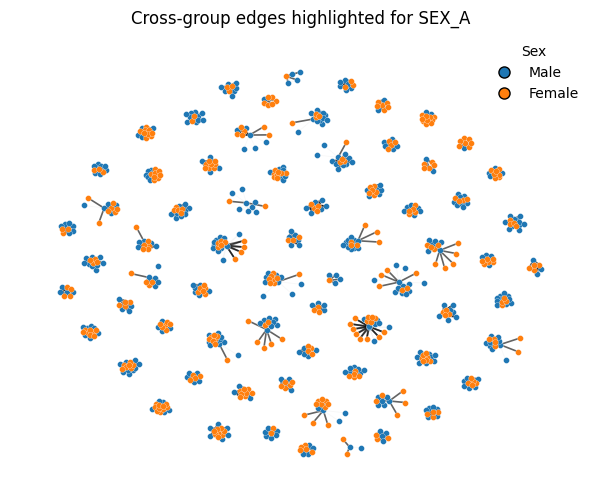

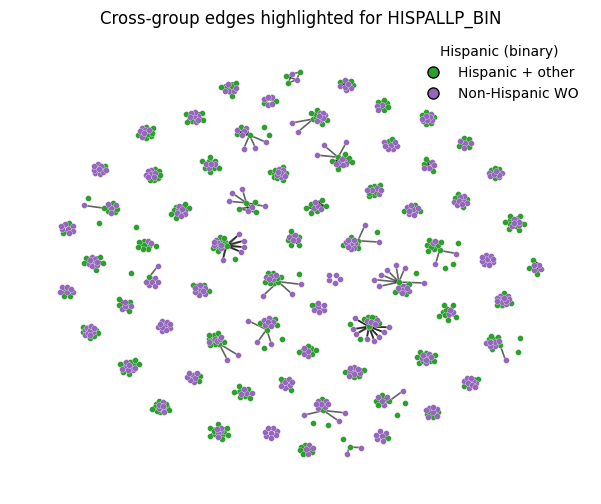

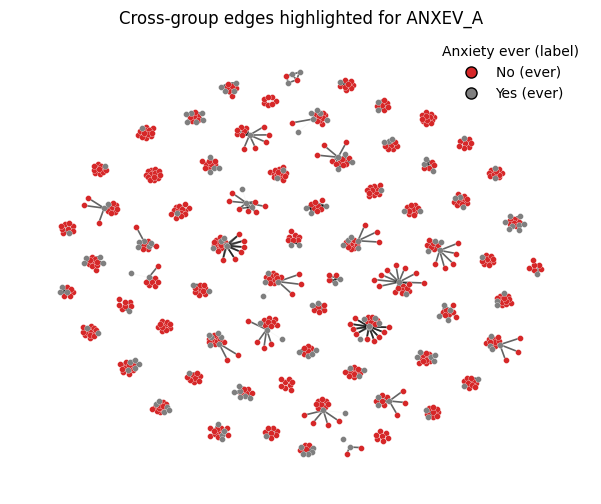

In [29]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from scipy.sparse import triu

# share Layout for all graphs
deg = np.asarray(A.sum(axis=1)).ravel()
p = deg / deg.sum() if deg.sum() > 0 else None
rng = np.random.default_rng(0)
k_vis = min(800, n)   # tweak as you like
sample_idx = np.sort(rng.choice(n, size=k_vis, replace=False, p=p))

As = A[sample_idx][:, sample_idx].tocsr()
U = triu(As, k=1).tocoo()     # undirected edges once
eu, ev, ew = U.row, U.col, U.data

G = nx.Graph()
G.add_weighted_edges_from(zip(eu, ev, ew))
pos = nx.spring_layout(G, seed=0, iterations=60)  # fixed layout across plots

# customization of colors and labels
DEFAULT_SEQ = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
               "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]

PALETTES = {
    "SEX_A":        {0:"#1f77b4", 1:"#ff7f0e"},        # blue / orange
    "HISPALLP_BIN": {0:"#2ca02c", 1:"#9467bd"},        # green / purple
    "ANXEV_A":      {0:"#d62728", 1:"#7f7f7f"},        # red / gray
}


READABLE_TITLE = {
    "SEX_A": "Sex",
    "HISPALLP_BIN": "Hispanic (binary)",
    "ANXEV_A": "Anxiety ever (label)",
}


READABLE_LABEL = {
    "SEX_A":        {0: "Male", 1: "Female"},
    "HISPALLP_BIN": {0: "Hispanic + other", 1: "Non-Hispanic WO"},
    "ANXEV_A":      {0: "No (ever)",   1: "Yes (ever)"},
}

def _readable_label_for(attr_col, value):
    m = READABLE_LABEL.get(attr_col, {})
    
    if value in m:
        return m[value]
    try:
        iv = int(value)
        if iv in m:
            return m[iv]
    except Exception:
        pass
    return str(value)


def _exp_same_baseline(vals_u, vals_v, w=None):
    # sum_i p_i^2 over endpoint shares
    endpoints = np.concatenate([vals_u, vals_v])
    if w is None:
        _, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes) / codes.size
    else:
        ww = np.concatenate([w, w])
        _, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes, weights=ww) / ww.sum()
    return float((shares**2).sum())

def _colors_for_attr(attr_col, vals):
    # map each category to a fixed hex color
    cats = list(np.unique(vals))
    pal = PALETTES.get(attr_col, {})
    colors = []
    for i, c in enumerate(cats):
        colors.append(pal.get(c, DEFAULT_SEQ[i % len(DEFAULT_SEQ)]))
    color_by_cat = dict(zip(cats, colors))
    return cats, color_by_cat

def draw_attr(attr_col, highlight="cross", node_size=18, edge_base="#CCCCCC"):
    # values for sampled nodes
    vals_all = nodes.loc[sample_idx, attr_col].to_numpy()
    cats, color_by_cat = _colors_for_attr(attr_col, vals_all)

    # for edge stats / highlighting
    vals_u = vals_all[eu]
    vals_v = vals_all[ev]
    same = (vals_u == vals_v)
    cross = ~same

    obs_same_unw = float(same.mean()) if same.size else np.nan
    obs_same_w   = float(ew[same].sum()) / float(ew.sum()) if ew.size and ew.sum()>0 else np.nan
    exp_same_unw = _exp_same_baseline(vals_u, vals_v, w=None)
    exp_same_w   = _exp_same_baseline(vals_u, vals_v, w=ew)
    nh_unw = (obs_same_unw - exp_same_unw) / (1 - exp_same_unw) if (1-exp_same_unw)>0 else np.nan

   
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # base edges faint
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=list(zip(eu, ev)), edge_color=edge_base, alpha=0.15, width=0.6)

    # emphasize selected edges
    sel = np.where(cross)[0] if highlight=="cross" else np.where(same)[0]
    edgelist = [(int(eu[i]), int(ev[i])) for i in sel]
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edgelist, edge_color="#000000", alpha=0.6, width=1.2)

    # nodes: draw per category with explicit hex colors
    for cat in cats:
        idx = np.where(vals_all == cat)[0]
        nx.draw_networkx_nodes(
            G, pos, nodelist=idx, node_color=color_by_cat[cat],
            node_size=node_size, linewidths=0.2, edgecolors="white", ax=ax
        )

    # legend using Readable labels
    handles = [plt.Line2D([0],[0], marker='o', color='none',
                          markerfacecolor=color_by_cat[c], markersize=8)
               for c in cats]
    labels  = [_readable_label_for(attr_col, c) for c in cats]
    title   = READABLE_TITLE.get(attr_col, attr_col)
    ax.legend(handles, labels, title=title, loc="best", frameon=False)

    ax.set_axis_off()
    ax.set_title(f"Cross-group edges highlighted for {attr_col}")
    
    plt.show()


# draw three graphs
draw_attr("SEX_A",        highlight="cross", node_size=18)
draw_attr("HISPALLP_BIN", highlight="cross", node_size=18)
draw_attr("ANXEV_A",      highlight="cross", node_size=18)


In [13]:
#Sweep for defining the best alpha and gama for community detection

# assumes A_age (CSR), nodes DataFrame with AGEP_A, SEX_A, HISPALLP_BIN, instance_weight
import numpy as np, pandas as pd
from scipy.sparse import coo_matrix, triu
import igraph as ig, leidenalg as la

def build_weighted(A_age, w_raw, alpha=0.5, eps=0.05):
    w = np.log1p(np.clip(w_raw, 0, None)).astype(float)
    if w.max() > w.min():
        w = (w - w.min()) / (w.max() - w.min())
    w = eps + (1-eps)*w
    C = A_age.tocoo()
    scale = (w[C.row] * w[C.col]) ** (0.5*alpha)
    W = coo_matrix((C.data*scale, (C.row, C.col)), shape=A_age.shape).tocsr()
    return ((W + W.T)*0.5).tocsr()

def r2_age(x, g, w=None):
    x = np.asarray(x, float); g = np.asarray(g)
    if w is None:
        mu = x.mean(); ss_tot = ((x-mu)**2).sum()
        df = pd.DataFrame({"x":x,"g":g}); m = df.groupby("g")["x"].mean(); n = df.groupby("g")["x"].size()
        ss_b = ((m-mu)**2 * n).sum()
    else:
        w = np.asarray(w, float); mu = (x*w).sum()/w.sum()
        ss_tot = (w*(x-mu)**2).sum()
        d = pd.DataFrame({"x":x,"g":g,"w":w})
        wg = d.groupby("g")["w"].sum()
        mg = d.groupby("g", observed=True)[["x","w"]].apply(lambda z: (z["x"]*z["w"]).sum()/z["w"].sum())
        ss_b = ((mg-mu)**2 * wg).sum()
    return float(ss_b/ss_tot) if ss_tot>0 else np.nan

def mi_bits(g, a, w=None, base=2.0):
    g = np.asarray(g); a = np.asarray(a)
    w = np.ones_like(g, float) if w is None else np.asarray(w, float)
    df = pd.DataFrame({"g":g,"a":a,"w":w})
    Pga = df.groupby(["g","a"])["w"].sum(); Z = Pga.sum(); Pga/=Z
    Pg = Pga.groupby(level=0).sum(); Pa = Pga.groupby(level=1).sum()
    mi = 0.0
    for (gi, ai), p in Pga.items():
        if p>0: mi += p * (np.log(p/(Pg[gi]*Pa[ai]))/np.log(base))
    return float(mi)

def leiden_on(W, gamma=0.3, seed=42):
    U = triu(W, 1).tocoo()
    g = ig.Graph(n=W.shape[0], edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
    g.es["weight"] = U.data.tolist()
    part = la.find_partition(g, la.RBConfigurationVertexPartition, weights="weight",
                             resolution_parameter=gamma, seed=seed)
    return np.asarray(part.membership, int), float(part.quality())

# sweep a few values (keep short)
for alpha in [0.25, 0.5, 0.75]:
    W = build_weighted(A_age, nodes["instance_weight"].to_numpy(), alpha=alpha, eps=0.05)
    for gamma in [0.2, 0.3, 0.4]:
        comm, Q = leiden_on(W, gamma=gamma)
        r2u = r2_age(nodes["AGEP_A"], comm, None)
        r2w = r2_age(nodes["AGEP_A"], comm, nodes["instance_weight"])
        mi_sex = mi_bits(comm, nodes["SEX_A"])
        mi_his = mi_bits(comm, nodes["HISPALLP_BIN"])
        print(f"alpha={alpha:.2f}, gamma={gamma:.2f} → k={comm.max()+1:4d}, Q={Q:.1f}, R2_age={r2u:.3f}/{r2w:.3f}, "
              f"MI(sex)={mi_sex:.3f}, MI(hisp)={mi_his:.3f}")



alpha=0.25, gamma=0.20 → k=  69, Q=653353.7, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.25, gamma=0.30 → k=  69, Q=652299.1, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.25, gamma=0.40 → k=  69, Q=651244.6, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.20 → k=  69, Q=488968.9, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.30 → k=  69, Q=488175.8, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.40 → k=  69, Q=487382.7, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.20 → k=  69, Q=368748.3, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.30 → k=  69, Q=368147.4, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.40 → k=  69, Q=367546.5, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034


In [14]:
# === Leiden on age graph reweighted by instance_weight (no heads, fixed joins) ===
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import load_npz, coo_matrix, triu
import igraph as ig
import leidenalg as la

# -------- paths --------
ADJ_PATH   = Path("A_graph_age_rbf.npz")          # age-only RBF similarity (unpruned)
NODES_PATH = Path("age_weight_pruned_nodes.csv")  # aligned to adjacency row order

# -------- params --------
GAMMA = 0.3   # lower => fewer/larger communities; higher => more/smaller
SEED  = 42
ALPHA = 0.5   # weight influence on edges; 0=ignore instance_weight

# -------- load --------
A_age = load_npz(ADJ_PATH).tocsr()
nodes = pd.read_csv(NODES_PATH).copy()
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)
assert A_age.shape[0] == len(nodes), f"Row mismatch: A has {A_age.shape[0]}, nodes has {len(nodes)}."

# clean types
for c in ["ANXEV_A","SEX_A","HISPALLP_BIN"]:
    if c in nodes.columns:
        nodes[c] = pd.to_numeric(nodes[c], errors="coerce").fillna(0).astype(int)
nodes["AGEP_A"] = pd.to_numeric(nodes["AGEP_A"], errors="coerce")
nodes["instance_weight"] = pd.to_numeric(nodes["instance_weight"], errors="coerce").fillna(0.0)

# -------- reweight edges by instance_weight (no pruning) --------
alpha = 0.5               # soften weight influence
w = np.log1p(nodes["instance_weight"].clip(lower=0).to_numpy(np.float64))
w = (w - w.min()) / (w.max() - w.min() + 1e-12)
eps = 0.05
w = eps + (1 - eps) * w   # floor at 0.05

C = A_age.tocoo()
scale = (w[C.row] * w[C.col]) ** (0.5 * alpha)
A_weighted = coo_matrix((C.data * scale, (C.row, C.col)), shape=A_age.shape).tocsr()
A_weighted = ((A_weighted + A_weighted.T) * 0.5).tocsr()

# -------- build igraph (one undirected edge per pair with weight) --------
U = triu(A_weighted, k=1).tocoo()
g = ig.Graph(n=A_weighted.shape[0], edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
g.es["weight"] = U.data.tolist()

# -------- Leiden (RB Configuration) --------
part = la.find_partition(
    g, la.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=GAMMA,
    seed=SEED
)
membership = np.asarray(part.membership, dtype=int)
quality = float(part.quality())
n_comm = int(membership.max() + 1)
print(f"Leiden: {n_comm} communities (gamma={GAMMA}), quality={quality:.4f}")

nodes["community"] = membership

# -------- helpers (weighted stats, variance explained, MI) --------
def wmean(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    s = w.sum()
    return (x*w).sum()/s if s > 0 else np.nan

def wvar(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    s = w.sum()
    if s <= 0: return np.nan
    mu = (x*w).sum()/s
    return (w*((x-mu)**2)).sum()/s

def variance_explained_by_groups(x, grp, w=None):
    x = np.asarray(x, float); g = np.asarray(grp)
    if w is None:
        mu = np.nanmean(x); ss_tot = np.nansum((x-mu)**2)
        df = pd.DataFrame({"x": x, "g": g})
        means = df.groupby("g", observed=True)["x"].mean()
        sizes = df.groupby("g", observed=True)["x"].size()
        ss_between = ((means - mu)**2 * sizes).sum()
    else:
        w = np.asarray(w, float)
        mu = wmean(x, w); ss_tot = wvar(x, w) * w.sum()
        d = pd.DataFrame({"x": x, "g": g, "w": w})
        wg = d.groupby("g", observed=True)["w"].sum()
        mg = d.groupby("g", observed=True)[["x","w"]].apply(lambda z: wmean(z["x"], z["w"]))
        ss_between = ((mg - mu)**2 * wg).sum()
    return float(ss_between / ss_tot) if ss_tot > 0 else np.nan

def mutual_information(group, attr, weights=None, base=2.0):
    g = np.asarray(group); a = np.asarray(attr)
    w = np.ones_like(g, float) if weights is None else np.asarray(weights, float)
    df = pd.DataFrame({"g": g, "a": a, "w": w})
    Pga = df.groupby(["g","a"], observed=True)["w"].sum()
    Z = Pga.sum(); Pga = Pga / Z
    Pg = Pga.groupby(level=0).sum(); Pa = Pga.groupby(level=1).sum()
    mi = 0.0
    for (gi, ai), p in Pga.items():
        if p > 0:
            mi += p * (np.log(p / (Pg[gi]*Pa[ai])) / np.log(base))
    return float(mi)

# -------- summaries (no .head prints) --------
summary = (nodes.groupby("community", observed=True)
           .agg(size=("community","size"),
                age_mean=("AGEP_A","mean"),
                age_std=("AGEP_A","std"),
                pos_rate_unw=("ANXEV_A","mean"),
                weight_sum=("instance_weight","sum")))

# weighted age & outcome — use column subset to avoid FutureWarning
age_w = (nodes.groupby("community", observed=True)[["AGEP_A","ANXEV_A","instance_weight"]]
         .apply(lambda d: pd.Series({
             "age_mean_w": wmean(d["AGEP_A"], d["instance_weight"]),
             "age_std_w":  np.sqrt(wvar(d["AGEP_A"], d["instance_weight"])) if d["instance_weight"].sum()>0 else np.nan,
             "pos_rate_w": wmean(d["ANXEV_A"], d["instance_weight"])
         })))

summary = summary.join(age_w, how="left")

def comp_props(df, col, wcol, name_map=None):
    # unweighted proportions
    cu = (df.pivot_table(index="community", columns=col, values="AGEP_A",
                         aggfunc="count", fill_value=0, observed=True).astype(float))
    cu = cu.div(cu.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    # weighted proportions
    cw = (df.pivot_table(index="community", columns=col, values=wcol,
                         aggfunc="sum", fill_value=0.0, observed=True).astype(float))
    cw = cw.div(cw.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    # rename columns to readable, unique names to avoid overlaps
    if name_map is None:
        map_u = {k: f"p_{col}_{k}" for k in cu.columns}
        map_w = {k: f"p_{col}_{k}_w" for k in cw.columns}
    else:
        map_u = {k: name_map.get(k, f"p_{col}_{k}") for k in cu.columns}
        map_w = {k: (name_map.get(k, f"p_{col}_{k}") + "_w") for k in cw.columns}
    return cu.rename(columns=map_u), cw.rename(columns=map_w)

# compositions with readable names (prevents '0'/'1' overlaps)
if "SEX_A" in nodes.columns:
    sex_map = {0:"p_male", 1:"p_female"}
    su, sw = comp_props(nodes, "SEX_A", "instance_weight", sex_map)
    summary = summary.join(su, how="left").join(sw, how="left")

if "HISPALLP_BIN" in nodes.columns:
    hisp_map = {0:"p_hisp_plus_others", 1:"p_non_hisp_white"}
    hu, hw = comp_props(nodes, "HISPALLP_BIN", "instance_weight", hisp_map)
    summary = summary.join(hu, how="left").join(hw, how="left")

# save files (no heads)
summary.sort_values("size", ascending=False).to_csv("age_weight_leiden_summary.csv")
nodes[["node_id","community"] if "node_id" in nodes.columns else ["community"]].to_csv(
    "age_weight_leiden_membership.csv", index=False
)

print("Saved: age_weight_leiden_summary.csv, age_weight_leiden_membership.csv")

# -------- interpretable diagnostics (what forms communities?) --------
R2_age_unw = variance_explained_by_groups(nodes["AGEP_A"], nodes["community"], w=None)
R2_age_w   = variance_explained_by_groups(nodes["AGEP_A"], nodes["community"], w=nodes["instance_weight"])
print(f"Age variance explained by community: R^2_unw={R2_age_unw:.3f}, R^2_w={R2_age_w:.3f}")

mi_sex_unw = mutual_information(nodes["community"], nodes["SEX_A"]) if "SEX_A" in nodes.columns else np.nan
mi_his_unw = mutual_information(nodes["community"], nodes["HISPALLP_BIN"]) if "HISPALLP_BIN" in nodes.columns else np.nan
mi_lbl_unw = mutual_information(nodes["community"], nodes["ANXEV_A"])
mi_sex_w   = mutual_information(nodes["community"], nodes["SEX_A"], nodes["instance_weight"]) if "SEX_A" in nodes.columns else np.nan
mi_his_w   = mutual_information(nodes["community"], nodes["HISPALLP_BIN"], nodes["instance_weight"]) if "HISPALLP_BIN" in nodes.columns else np.nan
mi_lbl_w   = mutual_information(nodes["community"], nodes["ANXEV_A"], nodes["instance_weight"])

print(f"MI (bits) — SEX_A: unw={mi_sex_unw:.3f}, w={mi_sex_w:.3f}; "
      f"HISPALLP_BIN: unw={mi_his_unw:.3f}, w={mi_his_w:.3f}; "
      f"ANXEV_A: unw={mi_lbl_unw:.3f}, w={mi_lbl_w:.3f}")



Leiden: 69 communities (gamma=0.3), quality=488175.8021
Saved: age_weight_leiden_summary.csv, age_weight_leiden_membership.csv
Age variance explained by community: R^2_unw=1.000, R^2_w=1.000
MI (bits) — SEX_A: unw=0.004, w=0.005; HISPALLP_BIN: unw=0.034, w=0.037; ANXEV_A: unw=0.010, w=0.012


In [6]:
# Within-community age dispersion
age_std_by_comm = nodes.groupby("community")["AGEP_A"].std().fillna(0)
print("Median within-community age std:", age_std_by_comm.median())
print("Share of communities with std <= 1 year:", (age_std_by_comm <= 1).mean())

# Community size distribution
sizes = nodes["community"].value_counts().sort_values(ascending=False)
print("Median community size:", int(sizes.median()))
print("Communities with size <= 5:", int((sizes <= 5).sum()))


Median within-community age std: 0.0
Share of communities with std <= 1 year: 1.0
Median community size: 440
Communities with size <= 5: 0


Leiden: 69 communities
Share of communities with std <= 1.0 year: 1.000
Median community size: 440
Communities with size <= 5: 0


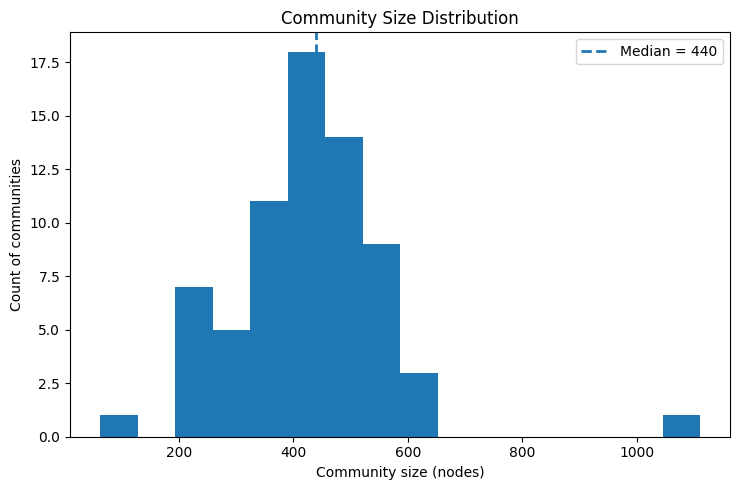

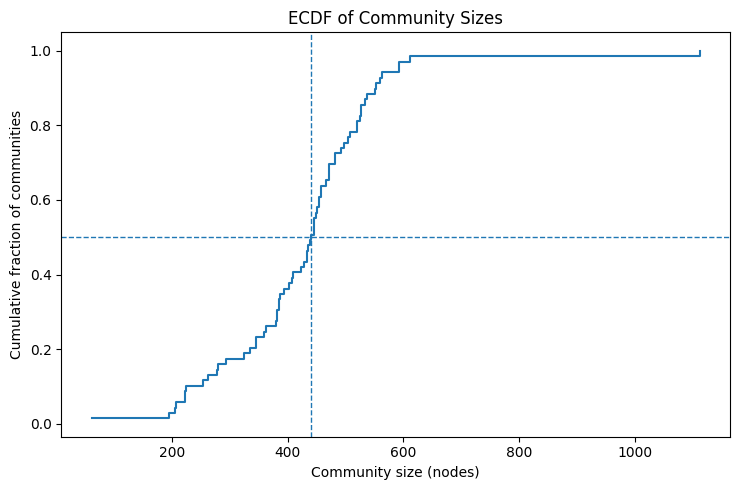

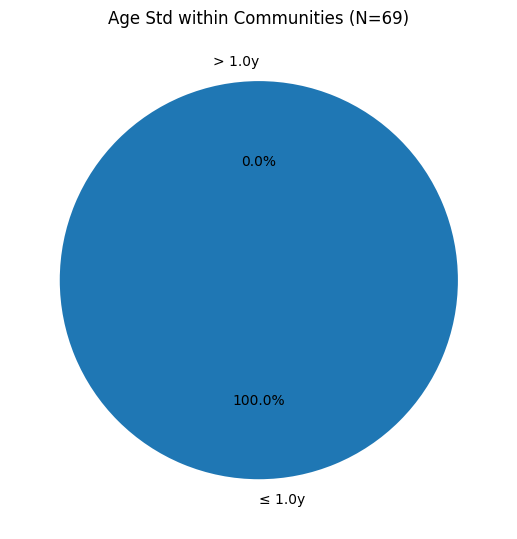

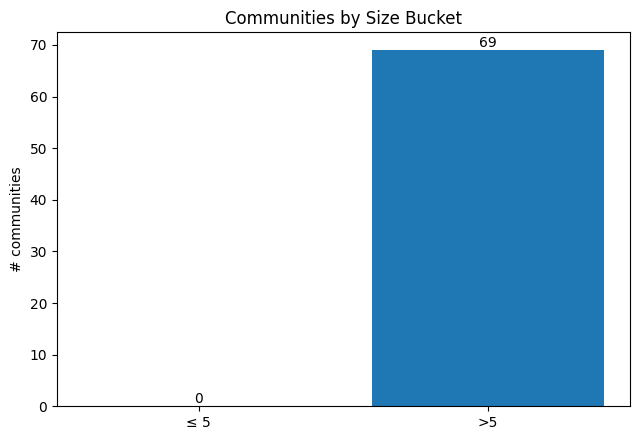

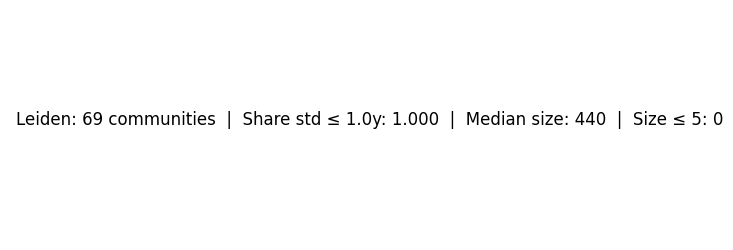

In [1]:
# Visualize community summary stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#  load summary 
summary_path = Path("age_weight_leiden_summary.csv")

summary = pd.read_csv(summary_path)

for col in ["community","size","age_std"]:
    if col not in summary.columns:
        raise ValueError(f"Missing column '{col}' in age_weight_leiden_summary.csv")

#  recompute the headline numbers 
N_COMM = int(summary["community"].nunique())
sizes  = summary.set_index("community")["size"].sort_values(ascending=False)

STD_THRESHOLD = 1.0  # "≤ 1 year"
age_std = pd.to_numeric(summary["age_std"], errors="coerce")
share_std_le1 = float((age_std <= STD_THRESHOLD).mean()) if len(age_std) > 0 else np.nan

median_size = int(np.median(sizes.values)) if len(sizes) > 0 else 0
small_thresh = 5
n_small = int((sizes <= small_thresh).sum())

print(f"Leiden: {N_COMM} communities")
print(f"Share of communities with std <= {STD_THRESHOLD} year: {share_std_le1:.3f}")
print(f"Median community size: {median_size}")
print(f"Communities with size <= {small_thresh}: {n_small}")

# Figure 1: Community size histogram 
plt.figure(figsize=(7.5, 5.0))
bins = "auto"  # let matplotlib pick
plt.hist(sizes.values, bins=bins)
plt.axvline(median_size, linestyle="--", linewidth=2, label=f"Median = {median_size}")
plt.title("Community Size Distribution")
plt.xlabel("Community size (nodes)")
plt.ylabel("Count of communities")
plt.legend()
plt.tight_layout()
plt.show()

#  Figure 2: ECDF of community sizes (shows median clearly at y=0.5) -
x = np.sort(sizes.values)
y = np.arange(1, len(x)+1) / len(x)
plt.figure(figsize=(7.5, 5.0))
plt.step(x, y, where="post")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(median_size, linestyle="--", linewidth=1)
plt.title("ECDF of Community Sizes")
plt.xlabel("Community size (nodes)")
plt.ylabel("Cumulative fraction of communities")
plt.tight_layout()
plt.show()

# Figure 3: Share with age std ≤ 1 year (pie chart)
n_le1  = int((age_std <= STD_THRESHOLD).sum())
n_gt1  = N_COMM - n_le1
plt.figure(figsize=(5.5, 5.5))
plt.pie([n_le1, n_gt1], labels=[f"≤ {STD_THRESHOLD}y", f"> {STD_THRESHOLD}y"],
        autopct="%1.1f%%", startangle=90)
plt.title(f"Age Std within Communities (N={N_COMM})")
plt.tight_layout()
plt.show()

#  Figure 4: “Small communities” bar (<= 5) 
plt.figure(figsize=(6.5, 4.5))
cats = [f"≤ {small_thresh}", f">{small_thresh}"]
vals = [n_small, N_COMM - n_small]
plt.bar(cats, vals)
for i, v in enumerate(vals):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.title("Communities by Size Bucket")
plt.ylabel("# communities")
plt.tight_layout()
plt.show()

#  a small KPI banner (text-only figure) 
plt.figure(figsize=(7.5, 2.6))
plt.axis("off")
txt = (f"Leiden: {N_COMM} communities  |  Share std ≤ {STD_THRESHOLD}y: {share_std_le1:.3f}  |  "
       f"Median size: {median_size}  |  Size ≤ {small_thresh}: {n_small}")
plt.text(0.01, 0.5, txt, fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipykernel_63609/354365637.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: wavg(d["AGEP_A"], d["instance_weight"]))


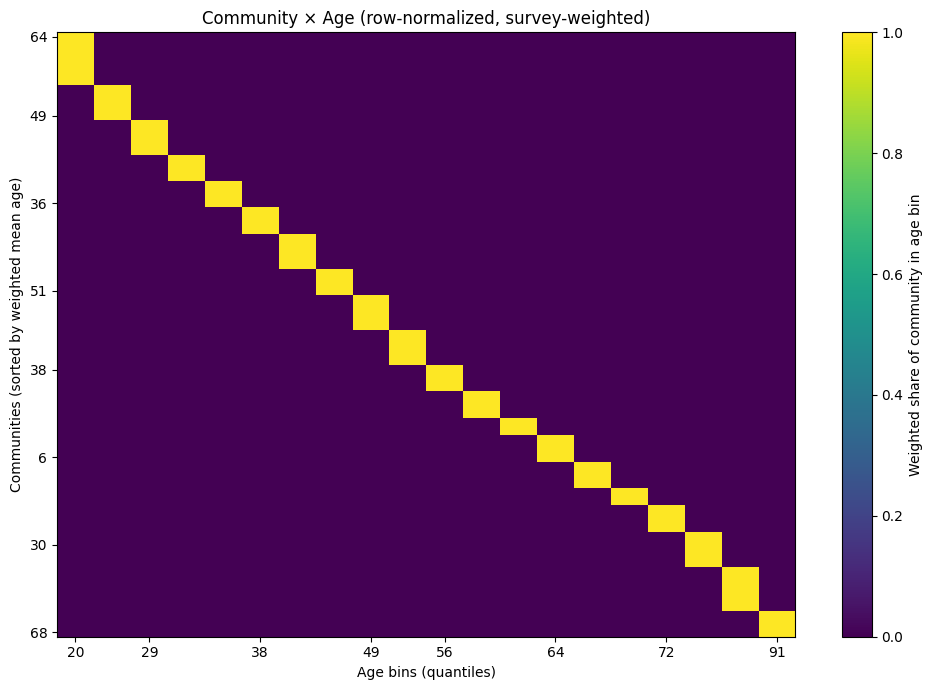

/tmp/ipykernel_63609/354365637.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({
/tmp/ipykernel_63609/354365637.py:119: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


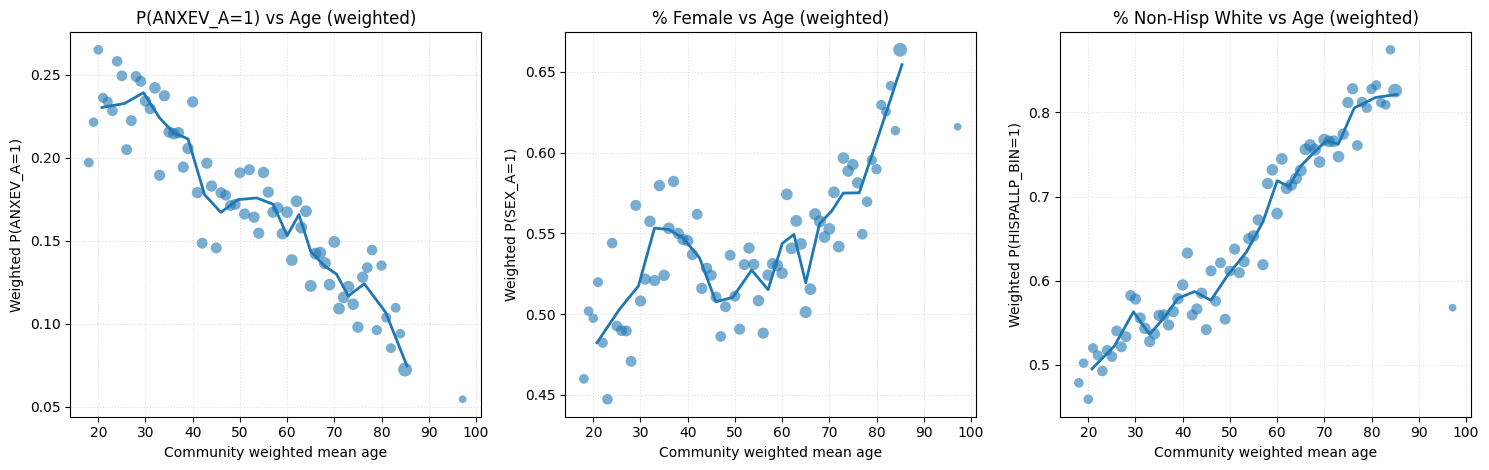

In [4]:
# === Weighted Figure 14 (heatmap) & Figure 15 (age-conditioned alignment) ===
# Inputs:
#   - age_weight_pruned_nodes.csv  (AGEP_A, SEX_A, HISPALLP_BIN, ANXEV_A, instance_weight, node_id)
#   - age_weight_leiden_membership.csv  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load & align 
nodes_path = Path("age_weight_pruned_nodes.csv")
memb_path  = Path("age_weight_leiden_membership.csv")
if not nodes_path.exists() or not memb_path.exists():
    raise FileNotFoundError("Missing required CSVs. Need both files above.")

nodes = pd.read_csv(nodes_path)
memb  = pd.read_csv(memb_path)

# Align by node_id ; otherwise assume identical row order
if "node_id" in nodes.columns and "node_id" in memb.columns:
    df = (nodes.merge(memb[["node_id", "community"]], on="node_id", how="inner")
                .sort_values("node_id")
                .reset_index(drop=True))
else:
    if "community" not in memb.columns:
        raise ValueError("age_weight_leiden_membership.csv must contain a 'community' column.")
    df = nodes.copy()
    df["community"] = memb["community"].values

# Keep only needed columns & clean types
need = ["community","AGEP_A","SEX_A","HISPALLP_BIN","ANXEV_A","instance_weight"]
for c in need:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}' in merged data.")
df["AGEP_A"]          = pd.to_numeric(df["AGEP_A"], errors="coerce")
df["SEX_A"]           = pd.to_numeric(df["SEX_A"], errors="coerce").fillna(0).astype(int)
df["HISPALLP_BIN"]    = pd.to_numeric(df["HISPALLP_BIN"], errors="coerce").fillna(0).astype(int)
df["ANXEV_A"]         = pd.to_numeric(df["ANXEV_A"], errors="coerce").fillna(0).astype(int)
df["instance_weight"] = pd.to_numeric(df["instance_weight"], errors="coerce").fillna(0.0)
df = df.dropna(subset=["AGEP_A"]).reset_index(drop=True)

#  helpers 
def quantile_bins(x, q=20):
    """Quantile bins + midpoints for plotting."""
    qcat = pd.qcut(x, q=q, duplicates="drop")
    bins = qcat.cat.categories  # IntervalIndex
    mids = np.array([0.5*(iv.left+iv.right) for iv in bins], dtype=float)
    return qcat, bins, mids

def wavg(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float)
    s = w.sum()
    return float(np.average(x, weights=w)) if s > 0 else np.nan

#  Community × Age heatmap (WEIGHTED)
N_BINS = 20
df = df.copy()
age_q, age_bins, _ = quantile_bins(df["AGEP_A"], q=N_BINS)
df["age_bin"] = age_q

# Weighted table: sum of instance_weight per (community, age_bin)
wtab = (df.groupby(["community","age_bin"], observed=True)["instance_weight"]
          .sum()
          .unstack(fill_value=0.0))

# Row-normalize by total weight in each community → P(age_bin | community) weighted
row_w = wtab.sum(axis=1).replace(0, np.nan)
tab_w = (wtab.T / row_w).T.fillna(0.0)

# Sort communities by WEIGHTED mean age → diagonal band if age-driven
age_mean_w_by_comm = (df.groupby("community", observed=True)
                        .apply(lambda d: wavg(d["AGEP_A"], d["instance_weight"]))
                        .sort_values())
tab_w = tab_w.reindex(index=age_mean_w_by_comm.index)

# Order columns left→right by age-bin lower edge
col_order = sorted(tab_w.columns, key=lambda iv: iv.left)
tab_w = tab_w.reindex(columns=col_order)

plt.figure(figsize=(10, 7))
plt.imshow(tab_w.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Weighted share of community in age bin")
plt.title("Community × Age (row-normalized, survey-weighted)")
plt.xlabel("Age bins (quantiles)")
plt.ylabel("Communities (sorted by weighted mean age)")

# x ticks as bin midpoints (sparse)
age_mids_sorted = np.array([0.5*(iv.left+iv.right) for iv in tab_w.columns], dtype=float)
nb = tab_w.shape[1]
xt = np.linspace(0, nb-1, 8).astype(int)
plt.xticks(xt, [f"{age_mids_sorted[i]:.0f}" for i in xt], rotation=0)

# y ticks sparse
nc = tab_w.shape[0]
yt = np.linspace(0, nc-1, 8).astype(int)
plt.yticks(yt, age_mean_w_by_comm.index[yt])
plt.tight_layout()
plt.show()

#  Age-conditioned alignment (WEIGHTED)
# Global, age-conditional weighted baselines
base_w = (df.groupby("age_bin", observed=True)
            .apply(lambda d: pd.Series({
                "base_anx_w":     wavg(d["ANXEV_A"],      d["instance_weight"]),
                "base_fem_w":     wavg(d["SEX_A"],        d["instance_weight"]),
                "base_nhwhite_w": wavg(d["HISPALLP_BIN"], d["instance_weight"]),
                "bin_age_mean_w": wavg(d["AGEP_A"],       d["instance_weight"]),
            }))
            .reset_index(drop=True))

xline = base_w["bin_age_mean_w"].to_numpy()
y_anx = base_w["base_anx_w"].to_numpy()
y_fem = base_w["base_fem_w"].to_numpy()
y_nhw = base_w["base_nhwhite_w"].to_numpy()

# Community-level weighted summaries
comm_w = (df.groupby("community", observed=True)
            .apply(lambda d: pd.Series({
                "age_mean_w":   wavg(d["AGEP_A"],       d["instance_weight"]),
                "size_unw":     len(d),
                "size_w":       d["instance_weight"].sum(),
                "rate_anx_w":   wavg(d["ANXEV_A"],      d["instance_weight"]),
                "p_fem_w":      wavg(d["SEX_A"],        d["instance_weight"]),
                "p_nhwhite_w":  wavg(d["HISPALLP_BIN"], d["instance_weight"]),
            }))
            .reset_index())

# Bubble size by weighted size (sqrt scaling for readability)
s = 10 + 90*np.sqrt(comm_w["size_w"]/comm_w["size_w"].max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
ax = axes[0]
ax.scatter(comm_w["age_mean_w"], comm_w["rate_anx_w"], s=s, alpha=0.6, edgecolors="none")
ax.plot(xline, y_anx, linewidth=2)
ax.set_title("P(ANXEV_A=1) vs Age (weighted)")
ax.set_xlabel("Community weighted mean age")
ax.set_ylabel("Weighted P(ANXEV_A=1)")
ax.grid(True, linestyle=":", alpha=0.4)

ax = axes[1]
ax.scatter(comm_w["age_mean_w"], comm_w["p_fem_w"], s=s, alpha=0.6, edgecolors="none")
ax.plot(xline, y_fem, linewidth=2)
ax.set_title("% Female vs Age (weighted)")
ax.set_xlabel("Community weighted mean age")
ax.set_ylabel("Weighted P(SEX_A=1)")
ax.grid(True, linestyle=":", alpha=0.4)

ax = axes[2]
ax.scatter(comm_w["age_mean_w"], comm_w["p_nhwhite_w"], s=s, alpha=0.6, edgecolors="none")
ax.plot(xline, y_nhw, linewidth=2)
ax.set_title("% Non-Hisp White vs Age (weighted)")
ax.set_xlabel("Community weighted mean age")
ax.set_ylabel("Weighted P(HISPALLP_BIN=1)")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()



/tmp/ipykernel_63609/675540867.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({
/tmp/ipykernel_63609/675540867.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


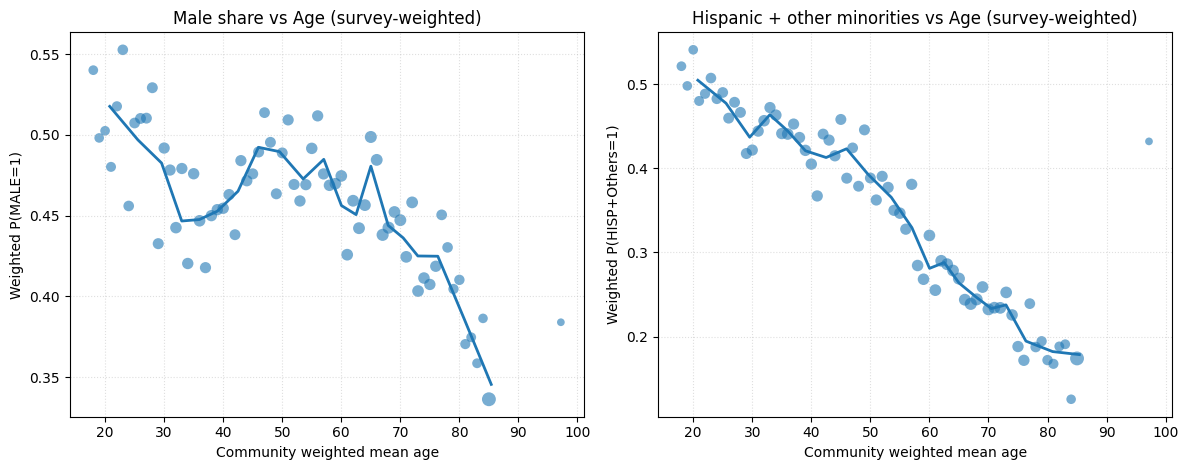

In [5]:
# Age-conditioned alignment (weighted) for Male and Hispanic+Others 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load & align 
nodes = pd.read_csv("age_weight_pruned_nodes.csv")
memb  = pd.read_csv("age_weight_leiden_membership.csv")

if "node_id" in nodes.columns and "node_id" in memb.columns:
    df = (nodes.merge(memb[["node_id","community"]], on="node_id", how="inner")
              .sort_values("node_id").reset_index(drop=True))
else:
    df = nodes.copy()
    df["community"] = memb["community"].values

# clean & ensure types
df["AGEP_A"]          = pd.to_numeric(df["AGEP_A"], errors="coerce")
df["SEX_A"]           = pd.to_numeric(df["SEX_A"], errors="coerce").fillna(0).astype(int)          # 0=Male, 1=Female
df["HISPALLP_BIN"]    = pd.to_numeric(df["HISPALLP_BIN"], errors="coerce").fillna(0).astype(int)   # 0=Hisp+Others, 1=NH White
df["instance_weight"] = pd.to_numeric(df["instance_weight"], errors="coerce").fillna(0.0)
df = df.dropna(subset=["AGEP_A"]).reset_index(drop=True)

# derive indicators we want to plot
df["MALE"]            = (1 - df["SEX_A"]).astype(int)          # 1 if Male
df["HISP_PLUS_OTH"]   = (1 - df["HISPALLP_BIN"]).astype(int)   # 1 if Hispanic + other minorities

#  helpers 
def wavg(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float)
    s = w.sum()
    return float(np.average(x, weights=w)) if s > 0 else np.nan

def quantile_bins(x, q=20):
    qcat = pd.qcut(x, q=q, duplicates="drop")
    mids = np.array([0.5*(iv.left+iv.right) for iv in qcat.cat.categories], float)
    return qcat, mids

# quantile bins for age (for smooth baseline line)
age_q, age_mids = quantile_bins(df["AGEP_A"], q=20)
df["age_bin"] = age_q

# global age-conditional (weighted) baselines 
base_w = (df.groupby("age_bin", observed=True)
            .apply(lambda d: pd.Series({
                "age_mid":           wavg(d["AGEP_A"],         d["instance_weight"]),
                "base_male_w":       wavg(d["MALE"],           d["instance_weight"]),
                "base_hispplus_w":   wavg(d["HISP_PLUS_OTH"],  d["instance_weight"]),
            }))
            .sort_values("age_mid")
            .reset_index(drop=True))

# community-level weighted summaries 
comm_w = (df.groupby("community", observed=True)
            .apply(lambda d: pd.Series({
                "age_mean_w":     wavg(d["AGEP_A"],        d["instance_weight"]),
                "size_w":         d["instance_weight"].sum(),
                "p_male_w":       wavg(d["MALE"],          d["instance_weight"]),
                "p_hispplus_w":   wavg(d["HISP_PLUS_OTH"], d["instance_weight"]),
            }))
            .reset_index())

# bubble size ∝ sqrt(weight) for readability
s = 10 + 90*np.sqrt(comm_w["size_w"]/comm_w["size_w"].max())

# plot (two panels) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

# Panel A: % Male vs age
ax = axes[0]
ax.scatter(comm_w["age_mean_w"], comm_w["p_male_w"], s=s, alpha=0.6, edgecolors="none")
ax.plot(base_w["age_mid"], base_w["base_male_w"], linewidth=2)
ax.set_title("Male share vs Age (survey-weighted)")
ax.set_xlabel("Community weighted mean age")
ax.set_ylabel("Weighted P(MALE=1)")
ax.grid(True, linestyle=":", alpha=0.4)

# Panel B: % Hispanic + other minorities vs age
ax = axes[1]
ax.scatter(comm_w["age_mean_w"], comm_w["p_hispplus_w"], s=s, alpha=0.6, edgecolors="none")
ax.plot(base_w["age_mid"], base_w["base_hispplus_w"], linewidth=2)
ax.set_title("Hispanic + other minorities vs Age (survey-weighted)")
ax.set_xlabel("Community weighted mean age")
ax.set_ylabel("Weighted P(HISP+Others=1)")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


In [19]:
# === Homophily summary (SEX_A, HISPALLP_BIN, ANXEV_A) in printed format ===
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import load_npz, csr_matrix, triu

# load adjacency (prefer what you just used)
def get_adj():
    try:
        return A_weighted.copy().tocsr()
    except NameError:
        pass
    if Path("age_weight_pruned_adjacency.npz").exists():
        return load_npz("age_weight_pruned_adjacency.npz").tocsr()
    return load_npz("A_graph_age_rbf.npz").tocsr()

A = get_adj().astype(np.float64).tocsr()
A.setdiag(0.0); A.eliminate_zeros()
A = ((A + A.T) * 0.5).tocsr()  # ensure symmetry

# one undirected edge per pair
U = triu(A, k=1).tocoo()
eu, ev, ew = U.row, U.col, U.data

# ---- load node attributes ----
nodes = pd.read_csv("age_weight_pruned_nodes.csv")
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)

# coerce binaries to {0,1}
for c in ["SEX_A", "HISPALLP_BIN", "ANXEV_A"]:
    if c in nodes.columns:
        nodes[c] = pd.to_numeric(nodes[c], errors="coerce").fillna(0).astype(int)

# ---- helpers ----
def weighted_homophily_from_edges(u, v, w, group01):
    same = (group01[u] == group01[v])
    num = float(w[same].sum())
    den = float(w.sum()) + 1e-12
    return num / den

def expected_same_endpoint_baseline(u, v, w, group01):
    # random mixing over edge endpoints (unweighted by default here)
    endpoints = np.concatenate([group01[u], group01[v]])
    counts = np.bincount(endpoints, minlength=2).astype(float)
    p = counts / counts.sum()
    return float((p**2).sum())

def mean_degree_per_group(A_csr: csr_matrix, group01):
    deg = np.asarray(A_csr.sum(1)).ravel()
    d0 = float(deg[group01 == 0].mean()) if (group01 == 0).any() else np.nan
    d1 = float(deg[group01 == 1].mean()) if (group01 == 1).any() else np.nan
    return d0, d1

def neighbor_same_group_exposure(A_csr: csr_matrix, group01):
    deg = (np.asarray(A_csr.sum(1)).ravel() + 1e-12)
    frac1 = np.asarray(A_csr.dot(group01)) / deg  # share of incident weight to group==1
    same = np.where(group01 == 1, frac1, 1.0 - frac1)
    e0 = float(same[group01 == 0].mean()) if (group01 == 0).any() else np.nan
    e1 = float(same[group01 == 1].mean()) if (group01 == 1).any() else np.nan
    return e0, e1

def print_structural_summary(name, group01, labels):
    h_obs = weighted_homophily_from_edges(eu, ev, ew, group01)
    h_exp = expected_same_endpoint_baseline(eu, ev, ew, group01)
    d0, d1 = mean_degree_per_group(A, group01)
    e0, e1 = neighbor_same_group_exposure(A, group01)
    print(f"{name}: homophily obs={h_obs:.3f} exp={h_exp:.3f} Δ={h_obs - h_exp:+.3f}")
    print(f"  mean degree: {labels[0]}={d0:.2f}, {labels[1]}={d1:.2f}")
    print(f"  same-group exposure: {labels[0]}={e0:.3f}, {labels[1]}={e1:.3f}")

# ---- run summaries ----
if {"SEX_A","HISPALLP_BIN","ANXEV_A"}.issubset(nodes.columns):
    g_sex  = nodes["SEX_A"].to_numpy(int)              # 0=Male, 1=Female
    g_hisp = nodes["HISPALLP_BIN"].to_numpy(int)       # 0=Hisp+Others, 1=Non-Hisp White
    g_lbl  = nodes["ANXEV_A"].to_numpy(int)            # 0=No, 1=Yes

    print_structural_summary("SEX",  g_sex,  {0:"Male", 1:"Female"})
    print_structural_summary("HISP", g_hisp, {0:"Hisp+Others", 1:"Non-Hisp White"})
    print_structural_summary("ANXEV_A", g_lbl, {0:"No", 1:"Yes"})
else:
    missing = {"SEX_A","HISPALLP_BIN","ANXEV_A"} - set(nodes.columns)
    raise ValueError(f"Missing required columns in nodes CSV: {missing}")


SEX: homophily obs=0.504 exp=0.503 Δ=+0.001
  mean degree: Male=16.95, Female=16.40
  same-group exposure: Male=0.467, Female=0.534
HISP: homophily obs=0.568 exp=0.550 Δ=+0.019
  mean degree: Hisp+Others=16.85, Non-Hisp White=16.55
  same-group exposure: Hisp+Others=0.376, Non-Hisp White=0.666
ANXEV_A: homophily obs=0.740 exp=0.703 Δ=+0.037
  mean degree: No=17.24, Yes=14.04
  same-group exposure: No=0.846, Yes=0.164


In [ ]:
#Code sources

#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.connected_components.html
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.rbf_kernel.html
#https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.save_npz.html
#https://leidenalg.readthedocs.io/en/stable/intro.html
#https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
#https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
#https://www.youtube.com/watch?v=Nz73vXn5afE
#https://www.youtube.com/watch?v=9-sIgMrMPuY
#https://youtu.be/gGdlYicGIIo?si=tElphyYBEvXdA0Tx
#https://www.geeksforgeeks.org/machine-learning/radial-basis-function-kernel-machine-learning/
#https://machinelearningmastery.com/normalize-standardize-time-series-data-python/
#https://www.youtube.com/watch?v=94f_bId5HGI
#https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/
#https://www.w3schools.com/python/python_ml_knn.asp
#https://towardsdatascience.com/k-nearest-neighbor-classifier-explained-a-visual-guide-with-code-examples-for-beginners-a3d85cad00e1/
#https://medium.com/analytics-vidhya/implementing-k-nearest-neighbours-knn-without-using-scikit-learn-3905b4decc3c
#https://medium.com/@swapnil.agashe456/leiden-clustering-for-community-detection-a-step-by-step-guide-with-python-implementation-c883933a1430
#https://github.com/CWTSLeiden/networkanalysis
#https://github.com/vtraag/leidenalg
#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.assortativity.attribute_assortativity_coefficient.html
#https://graph-tool.skewed.de/static/docs/stable/autosummary/graph_tool.correlations.assortativity.html
#https://pytorch-geometric.readthedocs.io/en/2.1.0/_modules/torch_geometric/utils/homophily.html



